# Jellybean Color Segmentation

This notebook compares RGB, HSV, LAB, K-Means, and hybrid segmentation methods for separating jellybean colors.


In [ ]:
!git clone https://github.com/dmc27/ai2025.git

Cloning into 'ai2025'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 24 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 3.30 MiB | 5.47 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
import numpy as np
import cv2 as cv
from ai2025.imutils import imshow, imshow_horz
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

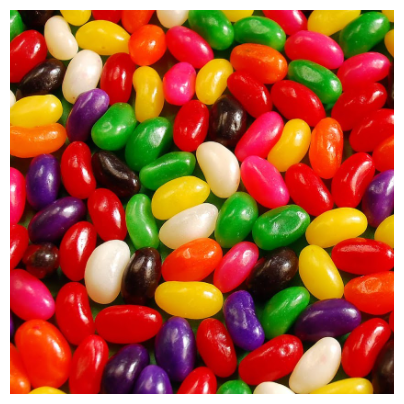

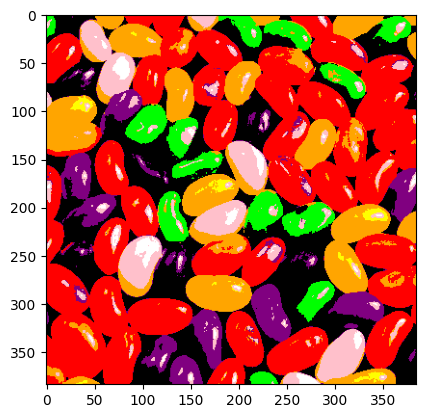

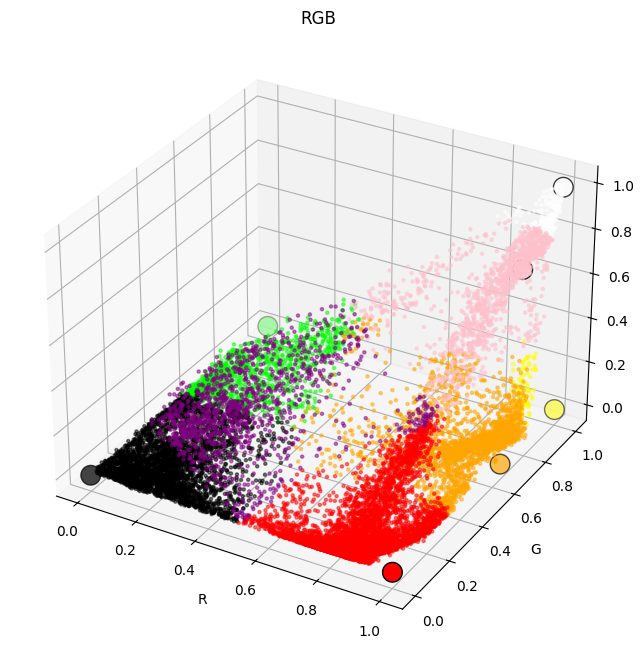

In [ ]:
img_bgr=cv.imread('/content/ai2025/jbeans.png')
img_rgb=cv.cvtColor(img_bgr,cv.COLOR_BGR2RGB)
img_rgb=img_rgb.astype(np.float32)/255.0
imshow(img_rgb)
colors_rgb=np.array([
    [255,0,0],
    [0,255,0],
    [128,0,128],
    [255,255,0],
    [255,165,0],
    [255,192,203],
    [255,255,255],
    [0,0,0]
])/255.0

def distance_segment(img_rgb,ref_colors,threshold=0.1):
  h,w,_=img_rgb.shape
  img_flat=img_rgb.reshape(-1,3)
  dist=np.linalg.norm(img_flat[:,None]-ref_colors[None,:],axis=2)
  labels=np.argmin(dist,axis=1)
  min_dist=np.min(dist,axis=1)
  labels[min_dist>threshold]=-1
  segmented=np.zeros_like(img_flat)


  for i in range(len(ref_colors)):
    segmented[labels==i]=ref_colors[i]
  segmented=segmented.reshape(h,w,3)

  segmented[labels.reshape(h,w)==-1]=0
  return segmented,labels

seg_rgb,labels=distance_segment(img_rgb,colors_rgb,threshold=1.0)

plt.imshow(seg_rgb)

fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(111,projection='3d')

pixels=img_rgb.reshape(-1,3)
segmented=colors_rgb[labels]
ax.scatter(pixels[::10,0],pixels[::10,1],pixels[::10,2],c=segmented[::10],s=5,alpha=0.5)
ax.scatter(colors_rgb[:,0],colors_rgb[:,1],colors_rgb[:,2],c=colors_rgb,s=200,edgecolor='black',marker='o')
ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')
ax.set_title('RGB')
plt.show()


#1.A - This is RGB - Distance Based Segmentation

Using Euclidean distance in RGB space, we achieved reasonably good segmentation of all 8 jellybean colors.
RGB does not separate luminance from chromatic content, and therefore performance is slightly light and shadow condition-dependent.
However, as the jellybeans are relatively well-lit, the RGB space still performed reasonably well.
Red, green, and yellow are well separated, but purples and dark colors get mixed up.

The threshold (1.0) was used for different Variation


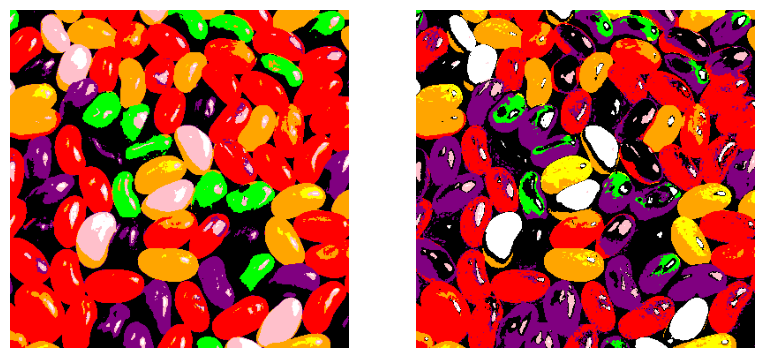

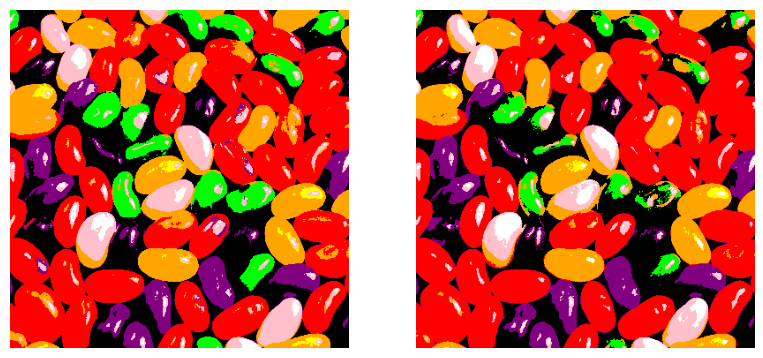

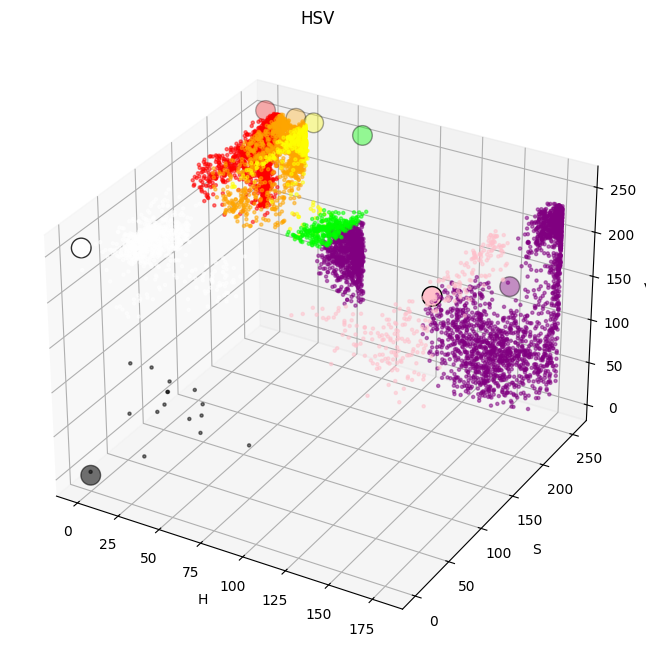

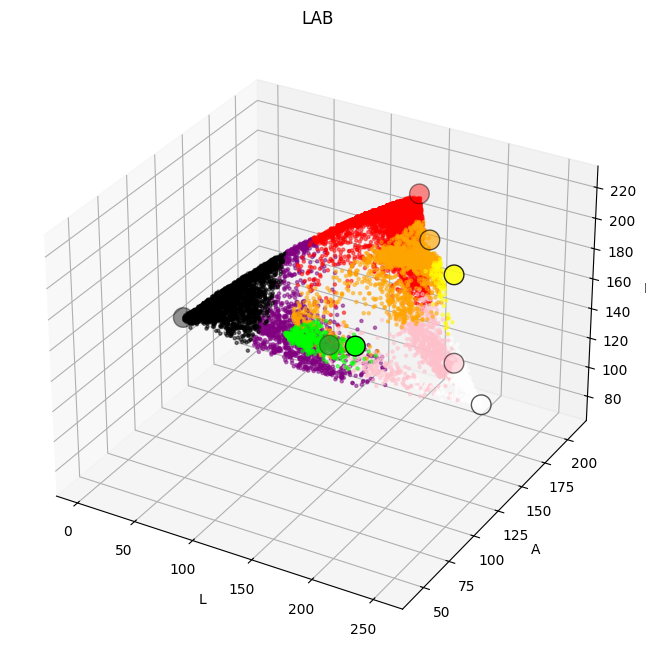

In [ ]:
def segment_image(img_bgr,color_space='HSV',threshold=0.1):
  if color_space=='HSV':
    img_space=cv.cvtColor(img_bgr,cv.COLOR_BGR2HSV)
    ref_colors=cv.cvtColor((colors_rgb*255).astype(np.uint8).reshape(-1,1,3),cv.COLOR_RGB2HSV).reshape(-1,3)
  elif color_space=='LAB':
    img_space=cv.cvtColor(img_bgr,cv.COLOR_BGR2LAB)
    ref_colors=cv.cvtColor((colors_rgb*255).astype(np.uint8).reshape(-1,1,3),cv.COLOR_RGB2LAB).reshape(-1,3)
  img_space=img_space.astype(np.float32)
  ref_colors=ref_colors.astype(np.float32)

  h,w, _=img_space.shape
  img_flat=img_space.reshape(-1,3)
  dist=np.linalg.norm(img_flat[:, None] - ref_colors[None, :],axis=2)
  labels=np.argmin(dist,axis=1)
  min_dist=np.min(dist,axis=1)
  labels[min_dist>threshold]= -1
  segmented=np.zeros_like(img_flat)


  for i in range(len(ref_colors)):
    segmented[labels==i]=colors_rgb[i]
  segmented=segmented.reshape(h,w,3)

  segmented[labels.reshape(h,w)==-1]=0
  return segmented,labels,img_flat

seg_hsv,labels_hsv,img_flat_hsv=segment_image(img_bgr, 'HSV',threshold=110)
seg_lab,labels_lab,img_flat_lab=segment_image(img_bgr, 'LAB',threshold=90)

imshow_horz(seg_rgb,seg_hsv)
imshow_horz(seg_rgb,seg_lab)


ref_colors_hsv=cv.cvtColor((colors_rgb*255).astype(np.uint8).reshape(-1,1,3),cv.COLOR_RGB2HSV).reshape(-1,3)
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(111,projection='3d')
mask_hsv=labels_hsv!=-1
mask_lab=labels_lab!=-1

ax.scatter(img_flat_hsv[mask_hsv][::10, 0], img_flat_hsv[mask_hsv][::10, 1], img_flat_hsv[mask_hsv][::10, 2],
           c=colors_rgb[labels_hsv[mask_hsv]][::10], s=5, alpha=0.5)

ax.scatter(ref_colors_hsv[:, 0], ref_colors_hsv[:, 1], ref_colors_hsv[:, 2],
           c=colors_rgb, s=200, edgecolor='black', marker='o')

ax.set_xlabel('H')
ax.set_ylabel('S')
ax.set_zlabel('V')
ax.set_title('HSV')
plt.show()

ref_colors_lab=cv.cvtColor((colors_rgb*255).astype(np.uint8).reshape(-1,1,3),cv.COLOR_RGB2LAB).reshape(-1,3)
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(111,projection='3d')

ax.scatter(img_flat_lab[mask_lab][::10, 0], img_flat_lab[mask_lab][::10, 1], img_flat_lab[mask_lab][::10, 2],
           c=colors_rgb[labels_lab[mask_lab]][::10], s=5, alpha=0.5)

ax.scatter(ref_colors_lab[:, 0], ref_colors_lab[:, 1], ref_colors_lab[:, 2],
           c=colors_rgb, s=200, edgecolor='black', marker='o')

ax.set_xlabel('L')
ax.set_ylabel('A')
ax.set_zlabel('B')
ax.set_title('LAB')
plt.show()




#1.B,C - HSV and LAB segmentation also Image compared with RGB

In HSV color space, we saw better resistance to lighting changes because the intensity component value was separated from the chromatic content (Hue).
More consistent jellybean detection across the image was done with this. Improvement in shadow areas was facilitated by a higher Value threshold
while using tighter thresholds for Hue and Saturation prevented misidentification of similar-value hues (pink and red also some of other jellybean i didnt get the smoother than RGB but compare to RGB some of the whit has identified).


The LAB space offered the best visual grouping of near colors and was brightness invariant. It even did a better job in the discrimination of the blacks and the purples as the channels represented chromatic change independently. LAB also did its best to divide the white from the pink jellybeans clearly.

So overall comparision LAB worked well also mapped properly in the image compared to RGB and HSV


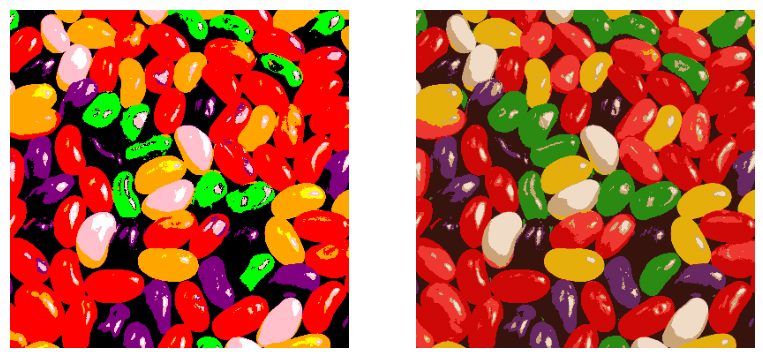

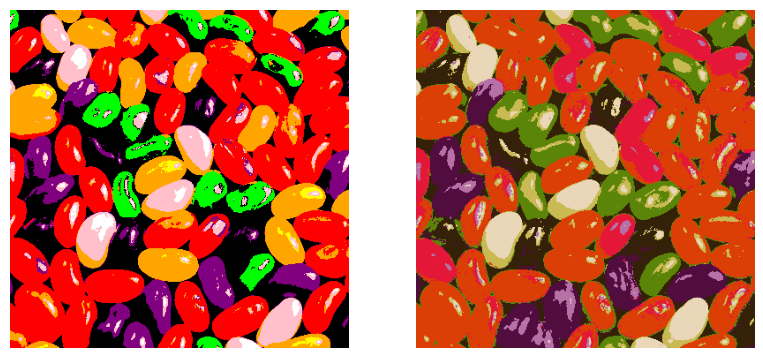

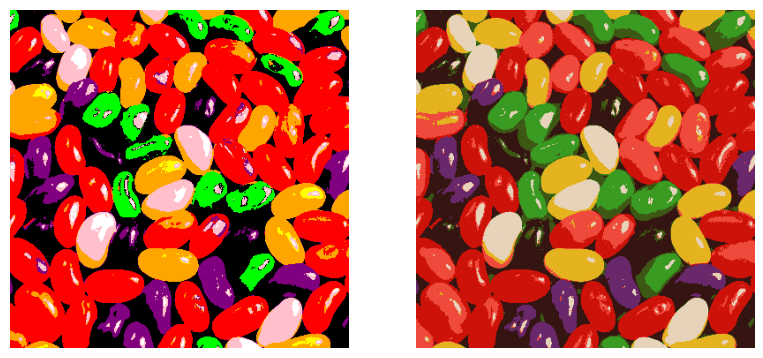

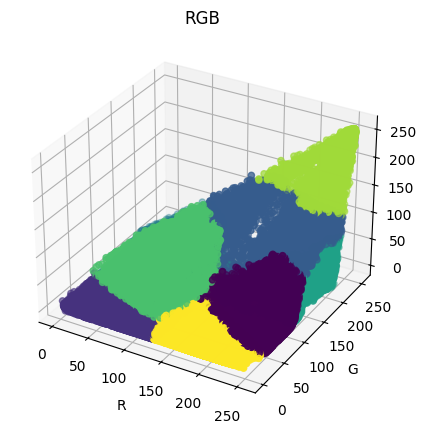

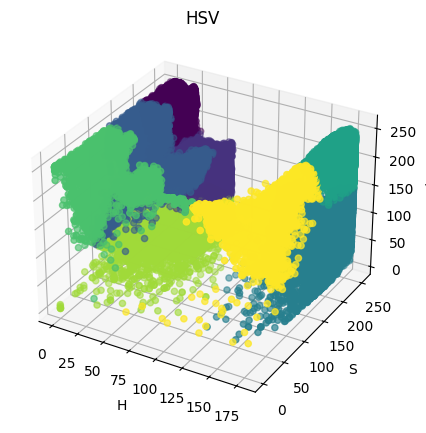

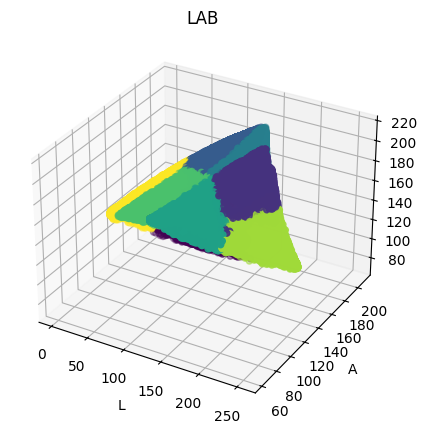

In [ ]:
def kmeans_segment(img_rgb, color='HSV', n_clusters=8):
    if color == 'HSV':
        img_space = cv.cvtColor((img_rgb * 255).astype(np.uint8), cv.COLOR_RGB2HSV).astype(np.float32)
    elif color == 'LAB':
        img_space = cv.cvtColor((img_rgb * 255).astype(np.uint8), cv.COLOR_RGB2LAB).astype(np.float32)
    else:
        img_space = img_rgb * 255

    h, w, _ = img_space.shape
    img_flat = img_space.reshape(-1, 3)

    kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    kmeans.fit(img_flat)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_
    segmented = centers[labels].reshape(h, w, 3)


    if color == 'HSV':
        segmented = cv.cvtColor(segmented.astype(np.uint8), cv.COLOR_HSV2RGB)
    elif color == 'LAB':
        segmented = cv.cvtColor(segmented.astype(np.uint8), cv.COLOR_LAB2RGB)
    else:
        segmented = segmented.astype(np.uint8)

    return segmented / 255.0, img_flat, labels, centers

seg_kmeans_rgb,img_flat_rgb,labels_rgb,centers_rgb=kmeans_segment(img_rgb,'RGB')
seg_kmeans_hsv,img_flat_hsv,labels_hsv,centers_hsv=kmeans_segment(img_rgb,'HSV')
seg_kmeans_lab,img_flat_lab,labels_lab,centers_lab=kmeans_segment(img_rgb,'LAB')

imshow_horz(seg_rgb,seg_kmeans_rgb)
imshow_horz(seg_rgb,seg_kmeans_hsv)
imshow_horz(seg_rgb,seg_kmeans_lab)

fig=plt.figure(figsize=(15,5))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(img_flat_rgb[:,0],img_flat_rgb[:,1],img_flat_rgb[:,2],c=labels_rgb)
ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')
ax.set_title('RGB')
plt.show()

fig=plt.figure(figsize=(15,5))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(img_flat_hsv[:,0],img_flat_hsv[:,1],img_flat_hsv[:,2],c=labels_hsv)
ax.set_xlabel('H')
ax.set_ylabel('S')
ax.set_zlabel('V')
ax.set_title('HSV')
plt.show()

fig=plt.figure(figsize=(15,5))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(img_flat_lab[:,0],img_flat_lab[:,1],img_flat_lab[:,2],c=labels_lab)
ax.set_xlabel('L')
ax.set_ylabel('A')
ax.set_zlabel('B')
ax.set_title('LAB')
plt.show()

#2 - K-Means algorithm for RGB,HSV,LAB

The k-means clustering algorithm groups pixels according to similarity with no a-priori knowledge of color groups.
8 clusters is in accordance with the known number of flavors of jellybeans. In RGB, k-means gives pleasing regions but may group visually separable colors with the same intensity since it doesn't have perceptual separation.

HSV k-means fixes this by giving prominent weight to Hue, though border colors like orange vs. red may still get grouped incorrectly.
LAB clustering produces the most perceptually meaningful clusters, achieving the maximum perceptual differentiation of all 8 color types,
even close ones like pink vs. white.

However k-means is not without weaknesses: it's unsupervised, and based on initialization may merge or divide regions inappropriately.
But LAB-kmeans performs nearly well compared to the other.


shape of image:(384, 384, 3)
shape of hybrid image:(147456, 3)
shape of labels:(147456,)


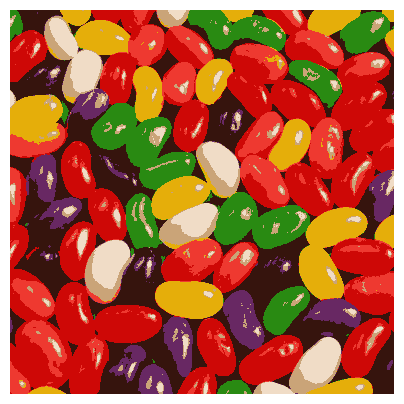

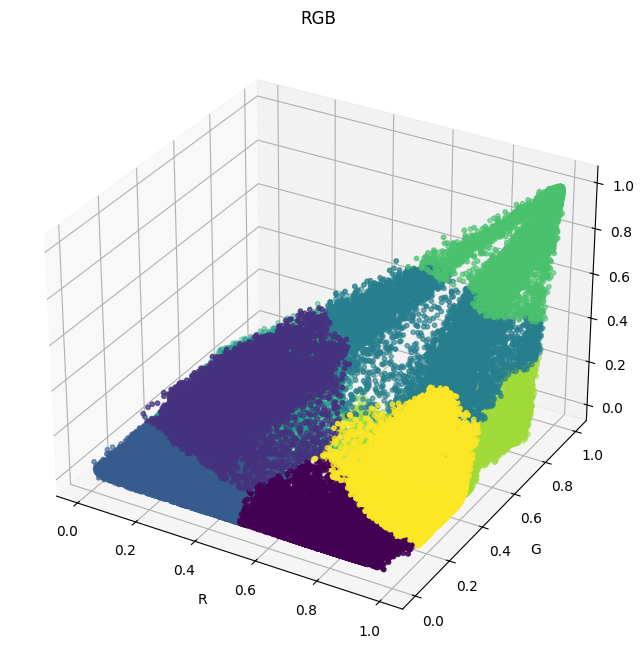

In [ ]:
def distance_segment(img_rgb,centers):
  h,w,_=img_rgb.shape
  img_flat=img_rgb.reshape(-1,3)
  dist=np.linalg.norm(img_flat[:,np.newaxis]-centers,axis=2)
  labels=np.argmin(dist,axis=1)
  segmented=centers[labels]
  return segmented.reshape(h,w,3)

def hybrid(img_rgb,n_clusters=8):
  h,w,_=img_rgb.shape
  img_flat=img_rgb.reshape(-1,3)
  kmeans=KMeans(n_clusters=n_clusters,n_init=10)
  kmeans.fit(img_flat)
  centers=kmeans.cluster_centers_
  hybrid_seg=distance_segment(img_rgb,centers)
  return hybrid_seg,img_flat,kmeans.labels_,centers

hybrid_seg,img_hybrid,hybrid_labels,hybrid_centers=hybrid(img_rgb)

print(f"shape of image:{img_rgb.shape}")
print(f"shape of hybrid image:{img_hybrid.shape}")
print(f"shape of labels:{hybrid_labels.shape}")

imshow(hybrid_seg)

fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(img_hybrid[:, 0], img_hybrid[:, 1], img_hybrid[:, 2], c=hybrid_labels, cmap='viridis', s=10)
ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')
ax.set_title('RGB')
plt.show()


#3 - Hybrid segmentation K-Means+Distance Based

Our hybrid method combines the unsupervised clustering strength of k-means with the structure of distance-based mapping.
We begin by learning 8 representative color clusters via k-means. Then we reassign pixels based on distance from
these learned centers.
ractically, the hybrid segmentation got most jellybean flavors right,
and generalized well across shades and lightings. It worked well.
